# Exemplo: Classificação multiclasse
------------------------------------

Este exemplo mostra como comparar o desempenho de três modelos em uma tarefa de classificação multiclasse.

Importe o conjunto de dados de vinhos de [sklearn.datasets](https://scikit-learn.org/stable/datasets/index.html#breast-cancer-wisconsin-diagnostic-dataset). Este é um conjunto de dados pequeno e fácil de treinar cujo objetivo é classificar os vinhos em três grupos, isto é, identificar de qual cultivador eles vêm, usando variáveis baseadas nos resultados de análises químicas.

## Carregar os dados

In [1]:
# Import packages
from sklearn.datasets import load_wine
from experionml import ExperionMLClassifier

In [2]:
# Carregue os dados
X, y = load_wine(return_X_y=True, as_frame=True)

# Let's have a look
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## Executar o pipeline

In [3]:
experionml = ExperionMLClassifier(X, y, n_jobs=1, verbose=2, random_state=1)

# Ajuste o pipeline com os modelos selecionados
experionml.run(
    models=["LR","LDA", "RF"],
    metric="roc_auc_ovr",
    n_trials=14,
    n_bootstrap=5,
    errors="raise",
)

<< ================== ExperionML ================== >>

Configuração ==================== >>
Tarefa do algoritmo: Multiclass classification.

Estatísticas do conjunto de dados ==================== >>
Formato: (178, 14)
Tamanho do conjunto de train: 143
Tamanho do conjunto de test: 35
-------------------------------------
Memória: 20.06 kB
Escalonado: False
Valores atípicos: 12 (0.6%)


Training ========================= >>
Models: LR, LDA, RF
Metric: roc_auc_ovr


Running hyperparameter tuning for LogisticRegression...
| trial | penalty |       C |  solver | max_iter | l1_ratio | roc_auc_ovr | best_roc_auc_ovr | time_trial | time_ht |    state |
| ----- | ------- | ------- | ------- | -------- | -------- | ----------- | ---------------- | ---------- | ------- | -------- |
| 0     |      l1 |  0.0054 |    saga |      480 |      0.7 |         0.5 |              0.5 |     0.048s |  0.048s | COMPLETE |
| 1     |      l1 |   0.122 |    saga |      380 |      0.7 |         1.0 |             

| 4     |      l2 |  0.0114 |     sag |      630 |      0.7 |         1.0 |              1.0 |     0.052s |  0.207s | COMPLETE |
| 5     |      l2 |  0.0018 |     sag |      920 |      0.1 |         1.0 |              1.0 |     0.042s |  0.249s | COMPLETE |
| 6     |      l2 | 43.4053 |     sag |      780 |      0.3 |         1.0 |              1.0 |     0.069s |  0.318s | COMPLETE |
| 7     |      l2 |  2.0759 | libli.. |      470 |      0.2 |         1.0 |              1.0 |     0.035s |  0.354s | COMPLETE |
| 8     |    None |   0.043 |     sag |      110 |      1.0 |         1.0 |              1.0 |     0.043s |  0.397s | COMPLETE |


| 9     |      l1 | 46.0233 |    saga |      740 |      0.1 |         1.0 |              1.0 |     0.093s |  0.490s | COMPLETE |
| 10    |      l2 |  0.4741 |   lbfgs |      280 |      1.0 |         1.0 |              1.0 |     0.048s |  0.538s | COMPLETE |
| 11    |      l2 |  0.0765 | newto.. |      370 |      0.5 |         1.0 |              1.0 |     0.086s |  0.624s | COMPLETE |


| 12    | elast.. |  0.5609 |    saga |      640 |      0.6 |         1.0 |              1.0 |     0.102s |  0.725s | COMPLETE |
| 13    |    None |  0.0481 | newto.. |      240 |      0.5 |         1.0 |              1.0 |     0.052s |  0.778s | COMPLETE |
Hyperparameter tuning ---------------------------
Best trial --> 1
Best parameters:
 --> penalty: l1
 --> C: 0.122
 --> solver: saga
 --> max_iter: 380
 --> l1_ratio: 0.7
Best evaluation --> roc_auc_ovr: 1.0
Time elapsed: 0.778s
Fit ---------------------------------------------
Train evaluation --> roc_auc_ovr: 0.9995


Test evaluation --> roc_auc_ovr: 0.9989
Time elapsed: 0.236s
Bootstrap ---------------------------------------
Evaluation --> roc_auc_ovr: 0.9991 ± 0.0009
Time elapsed: 0.198s


...

Time elapsed: 3.701s
Fit ---------------------------------------------
Train evaluation --> roc_auc_ovr: 0.999
Test evaluation --> roc_auc_ovr: 0.9986
Time elapsed: 0.083s


Bootstrap ---------------------------------------
Evaluation --> roc_auc_ovr: 0.9885 ± 0.0065
Time elapsed: 0.226s


-------------------------------------------------
Time: 4.010s


Resultados finais ==================== >>
Tempo total: 8.513s
-------------------------------------


LogisticRegression         --> roc_auc_ovr: 0.9991 ± 0.0009
LinearDiscriminantAnalysis --> roc_auc_ovr: 0.9998 ± 0.0005 !


RandomForest               --> roc_auc_ovr: 0.9885 ± 0.0065


## Analisar os resultados

In [4]:
experionml.results

,roc_auc_ovr_ht,time_ht,roc_auc_ovr_train,roc_auc_ovr_test,time_fit,roc_auc_ovr_bootstrap,time_bootstrap,time
LR,1.000000,0.777556,0.998700,0.998900,0.235583,0.999093,0.198321,1.211460
LDA,1.000000,0.111103,1.000000,0.998900,0.056995,0.999773,0.086074,0.254172
RF,0.998148,3.701473,0.999000,0.998600,0.082951,0.988525,0.225879,4.010303


In [5]:
# Mostre o score para algumas métricas diferentes
experionml.evaluate(["precision_macro", "recall_macro", "jaccard_weighted"])

,precision_macro,recall_macro,jaccard_weighted
LR,0.939400,0.952400,0.896100
LDA,0.966700,0.976200,0.945700
RF,0.911700,0.915300,0.842200


In [6]:
# Alguns gráficos permitem escolher a classe alvo a observar
experionml.rf.plot_probabilities(rows="train", target=0)

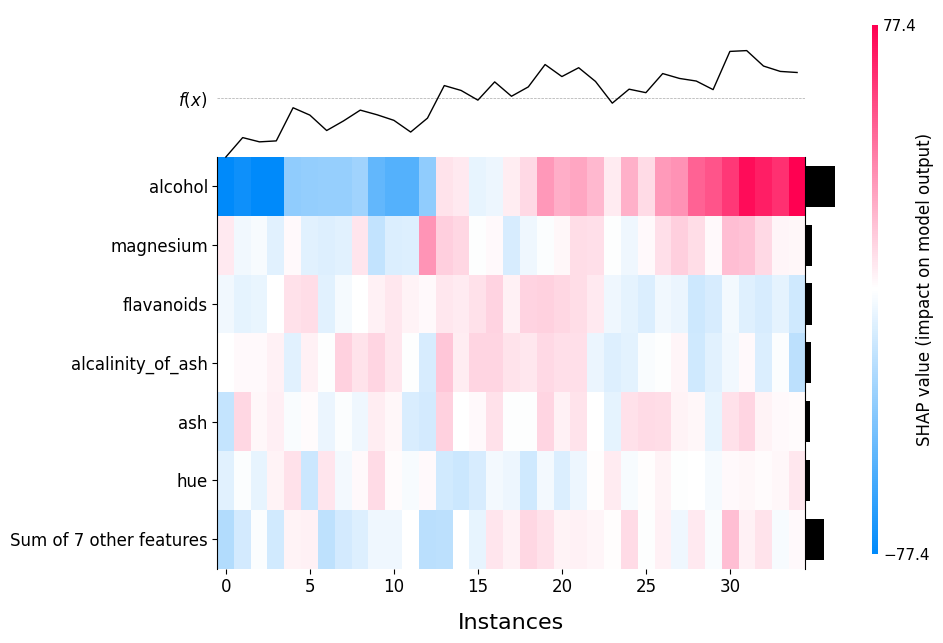

In [7]:
experionml.lda.plot_shap_heatmap(target=2, show=7)